## Table of Contents

1. [Introduction](#Introduction)
1. [Data Understanding](#Data-Understanding)
    1. [Data Dictionary](#Data-Dictionary)
        1. [Variable Notes](#Variable-Notes)
    1. [Descriptive Statistics](#Descriptive-Statistics)
    1. [Row Samples](#Row-Samples)
    1. [Data Types](#Data-Types)
    1. [Missing Values Summary](#Missing-Values-Summary)
    1. [Sample Visual Inspection](#Sample-Visual-Inspection)
1. [Feature Engineering](#Feature-Engineering)
1. [Exploratory Data Analysis](#Exploratory-Data-Analysis)
1. [Model Development](#Model-Development)
1. [Final Generalization Test](#Final-Generalization-Test)
1. [Submission File Generation](#Submission-File-Generation)

## Introduction

The sinking of the Titanic is one of the most infamous shipwrecks in history.

On April 15, 1912, during her maiden voyage, the widely considered “unsinkable” RMS Titanic sank after colliding with an iceberg. Unfortunately, there weren’t enough lifeboats for everyone onboard, resulting in the death of 1502 out of 2224 passengers and crew.

While there was some element of luck involved in surviving, it seems some groups of people were more likely to survive than others.

In this challenge, Kaggle asked us to build a predictive model that answers the question: **“What sorts of people were more likely to survive?”** using passenger data (e.g. name, age, gender, socio-economic class, etc).

In [574]:
from datetime import datetime
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import mlflow
import warnings
warnings.filterwarnings(
    "ignore",
    category=UserWarning,
    message=".*Inferred schema contains integer column.*",
    module="mlflow\\.types\\.utils"
)

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

import shap

## Data Understanding

Kaggle provided passenger data split into two files:
* "Training set" (<a href="./input/train.csv">train.csv</a>)
    * 891 rows, 12 features
* "Test set" (<a href="./input/test.csv">test.csv</a>)
    * 418 rows, 11 features (no `Survived` col)

As the "Test set" represents unseen data for use at submission time, I will refrain from loading the data at this time to mitigate data leakage risks.

To aid validating my models' generalizability to unseen data, I will set aside 20% of the Training Set data for final validation after optimizing model performance using cross-validation with the remaining Training Set data.

The `stratify=y` parameter was used to ensure equal distribution of the target variable across training and validation sets.

In [575]:
training_set_df = pd.read_csv('./input/train.csv')
target = 'Survived'

X = training_set_df.drop(columns=target)
y = training_set_df[target]

X_train, X_val, y_train, y_val = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

* New Training set contains 712 samples
* New Validation set contains 179 samples

In [576]:
X_train.shape, X_val.shape

((712, 11), (179, 11))

### Data Dictionary

| Variable | Definition | Key, Example |
| -------- | ---------- | --- |
| **Survived** | Survival | 0 = No, 1 = Yes |
| **PassengerId** | Integer index of passenger | 0,1,2,3,... |
| **Name** | Name of passenger including title | Braund, Mr. Owen Harris |
| **Pclass** | Ticket class | 1 = 1st, 2 = 2nd, 3 = 3rd |
| **Sex** | Sex | female, male |
| **Age** | Age in years | 0.15, 2, 15 |
| **SibSp** | # of siblings / spouses aboard the Titanic | 0,1,2,3,.. |
| **Parch** | # of parents / children aboard the Titanic | 0,1,2,3,.. |
| **Ticket** | Ticket number, some with prefixes, **shared among groups** | SW/PP 751 |
| **Fare** | Passenger fare, **shared among groups**	 | 7.91, 14.4542, 512.3292 |
| **Cabin** | Cabin number(s) listed on ticket, prefixed with deck letter, **shared among groups**	 | A20, "B57 B59 B63 B66"	 |
| **Embarked** | Port of Embarkation | C = Cherbourg (France), Q = Queenstown (Ireland), S = Southampton (England) |

#### Variable Notes

**pclass:** A proxy for socio-economic status (SES)
* 1st = Upper
* 2nd = Middle
* 3rd = Lower

**age:** Age is fractional if less than 1. If the age is estimated, is it in the form of xx.5

**sibsp:** The dataset defines family relations in this way...
* Sibling = brother, sister, stepbrother, stepsister
* Spouse = husband, wife (mistresses and fiancés were ignored)

**parch:** The dataset defines family relations in this way...
* Parent = mother, father
* Child = daughter, son, stepdaughter, stepson
* Some children travelled only with a nanny, therefore parch=0 for them.

### Descriptive Statistics

In [577]:
X_train.describe(include='number')

,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,712.000000,712.000000,575.000000,712.000000,712.000000,712.000000
mean,444.405899,2.308989,29.807687,0.492978,0.390449,31.819826
std,257.465527,0.833563,14.485211,1.060720,0.838134,48.059104
min,1.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,222.750000,2.000000,21.000000,0.000000,0.000000,7.895800
50%,439.500000,3.000000,28.500000,0.000000,0.000000,14.454200
75%,667.250000,3.000000,39.000000,1.000000,0.000000,31.000000
max,891.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Initial insights:
* **PassengerId:** column is most likely a sequential integer index from 1 to 891
* **Survived:** Mean survival rate for this data set is 38.4%
* **Pclass:** Top 25% of passengers were in 1st and 2nd Class, remainder in 3rd class
* **Age:** Youngest child was less than 6 months old, oldest is 80 years old.  Median age 28 yrs, 75th pecentile 38 yrs.  177 values missing
* **SibSp / Parch**:  At least 50% of passengers traveled alone, 75% passengers had at most 1 sibling or spouse.  Max family size is 8
* **Fare:** Fares ranged from 0.00 (potentially crew?) to 512.32.  Median fare 14.45, 75th percentile 31.00 - highest fares likely correlates with upper class

In [578]:
X_train.describe(include='object')

,Name,Sex,Ticket,Cabin,Embarked
count,712,712,712,160,710
unique,712,2,571,127,3
top,"Lam, Mr. Ali",male,1601,G6,S
freq,1,459,6,4,516


Initial insights:
* **Name:** Contains surname and title info, probable tokens for splitting
* **Sex:** Majority of passengers were male
* **Ticket:** Contains number; some contain prefixes with potentially useful info. 210 passengers shared the same ticket number, indicating traveling together (may be family and/or household staff)
* **Cabin:** Contains room number and deck letter prefix.  Some cabin strings contain multiple cabin numbers, may also signal family or household staff relationships.  687 values missing
* **Embarked:** Majority of passengers embarked from Southampton, England (644).  2 values missing

### Row Samples

In [579]:
X_train.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
692,693,3,"Lam, Mr. Ali",male,NaN,0,0,1601,56.4958,NaN,S
481,482,2,"Frost, Mr. Anthony Wood ""Archie""",male,NaN,0,0,239854,0.0000,NaN,S
527,528,1,"Farthing, Mr. John",male,NaN,0,0,PC 17483,221.7792,C95,S
855,856,3,"Aks, Mrs. Sam (Leah Rosen)",female,18.0,0,1,392091,9.3500,NaN,S
801,802,2,"Collyer, Mrs. Harvey (Charlotte Annie Tate)",female,31.0,1,1,C.A. 31921,26.2500,NaN,S


### Data Types

In [580]:
X_train.dtypes

PassengerId      int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

### Missing Values Summary

In [581]:
X_train.isnull().sum().loc[lambda x: x > 0]

Age         137
Cabin       552
Embarked      2
dtype: int64

### Sample Visual Inspection

Visual inspection shows variaion in **ticket prefixes**, **cabin numbers (e.g. multiple numbers)** and **name tokens (e.g. title, multiple names)**.

In [582]:
# Run multiple times to see different samples
X_train.sample(25)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
189,190,3,"Turcin, Mr. Stjepan",male,36.0,0,0,349247,7.8958,NaN,S
874,875,2,"Abelson, Mrs. Samuel (Hannah Wizosky)",female,28.0,1,0,P/PP 3381,24.0000,NaN,C
203,204,3,"Youseff, Mr. Gerious",male,45.5,0,0,2628,7.2250,NaN,C
798,799,3,"Ibrahim Shawah, Mr. Yousseff",male,30.0,0,0,2685,7.2292,NaN,C
123,124,2,"Webber, Miss. Susan",female,32.5,0,0,27267,13.0000,E101,S
48,49,3,"Samaan, Mr. Youssef",male,NaN,2,0,2662,21.6792,NaN,C
122,123,2,"Nasser, Mr. Nicholas",male,32.5,1,0,237736,30.0708,NaN,C
454,455,3,"Peduzzi, Mr. Joseph",male,NaN,0,0,A/5 2817,8.0500,NaN,S
206,207,3,"Backstrom, Mr. Karl Alfred",male,32.0,1,0,3101278,15.8500,NaN,S
481,482,2,"Frost, Mr. Anthony Wood ""Archie""",male,NaN,0,0,239854,0.0000,NaN,S


## Feature Engineering

In [583]:
def engineer_features(df):

    # Create Sex_Encoded feature
    df['Sex_Encoded'] = df['Sex'].map({'male': 0, 'female': 1})

    # Create Deck feature from CabinCabin
    df['Deck'] = df['Cabin'].str[0]

    # Fill missing Deck values with 'U' for Unknown
    df['Deck'] = df['Deck'].fillna('U')

    # Create Title feature from Name
    def extract_title(name):
        title = name.split(',')[1].split('.')[0].strip()
        return title
    df['Title'] = df['Name'].apply(extract_title)

    # Create Surname feature from Name
    def extract_surname(name):
        surname = name.split(',')[0].strip()
        return surname
    df['Surname'] = df['Name'].apply(extract_surname)

    # Create Ticket Prefix and Number features from Ticket
    def extract_ticket_info(ticket):
        if pd.isnull(ticket):
            return None, None
        parts = ticket.split()
        prefix = parts[0] if len(parts) > 1 else ''
        number = parts[-1] if len(parts) > 1 else parts[0]
        return prefix, number
    df[['Ticket_Prefix', 'Ticket_Number']] = df['Ticket'].apply(lambda x: pd.Series(extract_ticket_info(x)))

    # Print non-numeric Ticket Numbers in training data with counts
    non_numeric_ticket_numbers = df[~df['Ticket_Number'].str.isnumeric()]['Ticket_Number'].value_counts()
    print("Non-numeric Ticket Numbers in training data:")
    print(non_numeric_ticket_numbers)

    # Set 4 'LINE' Ticket Numbers to -1
    df.loc[df['Ticket_Number'].isin(['LINE']), 'Ticket_Number'] = -1

    # Create Ticket Frequency feature from Ticket Number on training data only
    #ticket_freq_train = X_train['Ticket_Number'].value_counts().to_dict()
    #df['Ticket_Frequency'] = df['Ticket_Number'].map(ticket_freq_train)

    # Calculate Fare per Person
    #df['Fare_Per_Person'] = df['Fare'] / df['Ticket_Frequency']
    #df['Fare_Per_Person_Scaled'] = (df['Fare_Per_Person'] - df['Fare_Per_Person'].mean()) / df['Fare_Per_Person'].std()

    # def bin_ticket_frequency(freq):
    #     if freq < 4:
    #         return freq
    #     else:
    #         return 4
    # df['Ticket_Frequency'] = df['Ticket_Frequency'].apply(bin_ticket_frequency)

    # Create Family Size feature
    df['Family_Size'] = df['SibSp'] + df['Parch'] + 1
    def bin_family_size(size):
        if size < 4:
            return size
        else:
            return 4
    df['Family_Size'] = df['Family_Size'].apply(bin_family_size)

    # Bin Parch and SibSp
    def bin_parch(parch):
        if parch < 3:
            return parch
        else:
            return 3
    df['Parch'] = df['Parch'].apply(bin_parch)

    def bin_sibsp(sibsp):
        if sibsp < 2:
            return sibsp
        else:
            return 2
    df['SibSp'] = df['SibSp'].apply(bin_sibsp)

    # Create Is_Alone feature
    df['Is_Alone'] = (df['Family_Size'] == 1).astype(int)

    # Create Cabin_Count feature from Cabin
    df['Cabin_Count'] = df['Cabin'].apply(lambda x: len(x.split()) if pd.notnull(x) else 0)
    def bin_cabin_count(cabin_count):
        if cabin_count < 2:
            return cabin_count
        else:
            return 2
    df['Cabin_Count'] = df['Cabin_Count'].apply(bin_cabin_count)

    # Create Cabin Number feature
    df['Cabin_Number'] = df['Cabin'].str.extract(r'(\d+)')

    # Create Port or Starboard feature based on Cabin Number
    def cabin_side(cabin_number):
        if pd.isnull(cabin_number):
            return 'Unknown'
        if cabin_number.isdigit():
            return 'Starboard' if int(cabin_number) % 2 == 0 else 'Port'
        return 'Unknown'
    df['Cabin_Side'] = df['Cabin_Number'].apply(cabin_side)

    # Create Cabin_Missing feature
    df['Cabin_Missing'] = df['Cabin'].isnull().astype(int)

    # Fill missing Cabin_Number values with 0
    df['Cabin_Number'] = df['Cabin_Number'].fillna(0).astype(int)

    # Drop original Cabin column
    df.drop(columns=['Cabin'], inplace=True)

    # Create Scaled Fare feature
    df['Fare_Scaled'] = (df['Fare'] - df['Fare'].mean()) / df['Fare'].std()

    # Create Age_Missing feature
    df['Age_Missing'] = df['Age'].isnull().astype(int)

    # Imput missing Age values using median of Pclass/Title gr
    def impute_age(df):

        # First attempt to impute by Pclass X Title
        pclass_title_age_median_map = df.groupby(['Pclass', 'Title'])['Age'].median()
        def impute_age_by_pclass_title(row):
            if pd.notna(row['Age']):
                return row['Age']
            return pclass_title_age_median_map.loc[row['Pclass'], row['Title']]
        df['Age'] = df.apply(impute_age_by_pclass_title, axis=1)

        # In the scenario where all ages for a given title are missing, impute with median age for Sex
        sex_age_median_map = df.groupby(['Sex'])['Age'].median()
        def impute_age_by_sex(row):
            if pd.notna(row['Age']):
                return row['Age']
            return sex_age_median_map.loc[row['Sex']]
        df['Age'] = df.apply(impute_age_by_sex, axis=1)
    impute_age(df)

    df['Is_Child'] = (df['Age'] < 10).astype(int)
    df['Age_Scaled'] = (df['Age'] - df['Age'].mean()) / df['Age'].std()

    return df


In [584]:
X_train = engineer_features(X_train)

Non-numeric Ticket Numbers in training data:
Ticket_Number
LINE    3
Name: count, dtype: int64


In [585]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 712 entries, 692 to 507
Data columns (total 26 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   PassengerId    712 non-null    int64  
 1   Pclass         712 non-null    int64  
 2   Name           712 non-null    object 
 3   Sex            712 non-null    object 
 4   Age            712 non-null    float64
 5   SibSp          712 non-null    int64  
 6   Parch          712 non-null    int64  
 7   Ticket         712 non-null    object 
 8   Fare           712 non-null    float64
 9   Embarked       710 non-null    object 
 10  Sex_Encoded    712 non-null    int64  
 11  Deck           712 non-null    object 
 12  Title          712 non-null    object 
 13  Surname        712 non-null    object 
 14  Ticket_Prefix  712 non-null    object 
 15  Ticket_Number  712 non-null    object 
 16  Family_Size    712 non-null    int64  
 17  Is_Alone       712 non-null    int32  
 18  Cabin_Count  

In [586]:
# Create categorical and numerical feature lists
target = 'Survived'
base_categorical_features = [] # TODO

base_numerical_features = [
    'Sex_Encoded', 'Pclass', 'SibSp', 'Parch', 'Family_Size', 'Cabin_Count',
    'Cabin_Number', 'Fare_Scaled', 'Age_Scaled', 'Is_Alone', 'Is_Child',
    'Cabin_Missing', 'Ticket_Number'
]

In [587]:
def remove_duplicates(X_df, features, y_df=None):
    """ Remove duplicate rows based on specified features. """

    # Combine features and target into a single DataFrame
    if y_df is None:
        y_df = pd.Series([None] * len(X_df), name='Target')
    df = pd.concat([X_df[features], y_df], axis=1)

    # Check for duplicates
    train_duplicates = df[features].duplicated().sum()
    print(f"Number of duplicate rows in train set: {train_duplicates}")

    # Drop duplicates to reduce multicollinearity
    X_df = X_df.drop_duplicates(subset=features)

    # Drop corresponding target values
    y_df = y_df[X_df.index]

    # Check for duplicates
    check_train_duplicates = X_df[features].duplicated().sum()
    print(f"Number of duplicate rows in train set after dropping: {check_train_duplicates}")

In [588]:
remove_duplicates(X_train, base_categorical_features + base_numerical_features, y_train)

Number of duplicate rows in train set: 7
Number of duplicate rows in train set after dropping: 0


In [589]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 712 entries, 692 to 507
Data columns (total 26 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   PassengerId    712 non-null    int64  
 1   Pclass         712 non-null    int64  
 2   Name           712 non-null    object 
 3   Sex            712 non-null    object 
 4   Age            712 non-null    float64
 5   SibSp          712 non-null    int64  
 6   Parch          712 non-null    int64  
 7   Ticket         712 non-null    object 
 8   Fare           712 non-null    float64
 9   Embarked       710 non-null    object 
 10  Sex_Encoded    712 non-null    int64  
 11  Deck           712 non-null    object 
 12  Title          712 non-null    object 
 13  Surname        712 non-null    object 
 14  Ticket_Prefix  712 non-null    object 
 15  Ticket_Number  712 non-null    object 
 16  Family_Size    712 non-null    int64  
 17  Is_Alone       712 non-null    int32  
 18  Cabin_Count  

## Exploratory Data Analysis

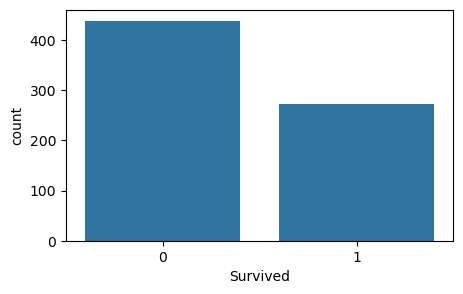

Global Survival Rate: 0.3834
Baseline Accuracy (if predicting majority class): 0.6166


In [590]:
y_df = pd.DataFrame(y_train).reset_index(drop=True)

plt.figure(figsize=(5, 3))
sns.countplot(x='Survived', data=y_df)
plt.show()

global_survival_rate = y_df['Survived'].mean()
print(f"Global Survival Rate: {global_survival_rate:.4f}")
print(f"Baseline Accuracy (if predicting majority class): {max(global_survival_rate, 1 - global_survival_rate):.4f}") 

In [591]:
def plot_corr_heatmap(feature_df, target_series, figsize=(10, 8)):
    """
    Plots a correlation heatmap for the given features and target.

    Args:
        df (pd.DataFrame): DataFrame containing the data.
        features (list): List of feature column names.
        target (str): Name of the target column.
        figsize (tuple): Figure size for the heatmap.
    """
    concat_df = pd.concat([feature_df, target_series], axis=1)
    correlation_matrix = concat_df.corr()
    plt.figure(figsize=figsize)
    sns.heatmap(
        correlation_matrix,
        annot=True,
        fmt=".2f",
        cmap='coolwarm',
        square=True,
        cbar_kws={"shrink": .8}
    )
    plt.title("Correlation Heatmap")
    plt.show()
    return correlation_matrix


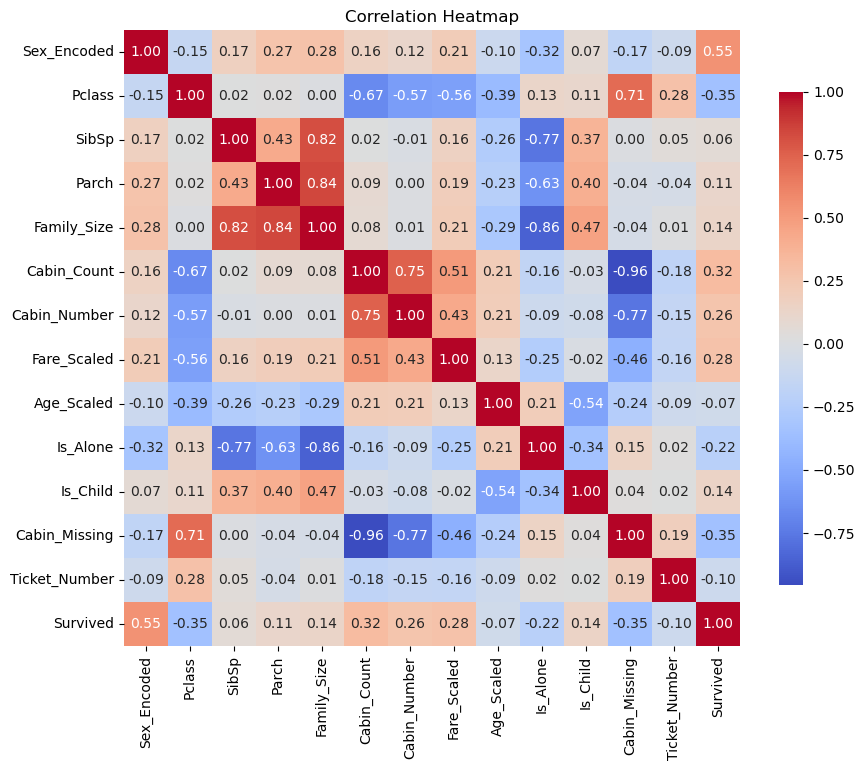

Correlation with target:
Survived         1.000000
Sex_Encoded      0.549171
Cabin_Count      0.321619
Fare_Scaled      0.275499
Cabin_Number     0.261415
Is_Child         0.139524
Family_Size      0.135502
Parch            0.114776
SibSp            0.063587
Age_Scaled      -0.074658
Ticket_Number   -0.098275
Is_Alone        -0.215570
Pclass          -0.348007
Cabin_Missing   -0.350535
Name: Survived, dtype: float64


In [592]:
correlation_matrix = plot_corr_heatmap(X_train[base_numerical_features], y_train)
correlation_with_target = correlation_matrix[target].sort_values(ascending=False)
print("Correlation with target:")
print(correlation_with_target)

In [593]:

vif_minimized_feature_list = [
    'Sex_Encoded',
    #'Cabin_Count',
    #'Fare_Scaled',
    #'Cabin_Number',
    #'Is_Child',
    #'Family_Size',
    #'Age_Scaled',
    #'Ticket_Number',
    #'Is_Alone',
    #'Pclass',
    #'Parch',
    #'SibSp',
    #'Cabin_Missing'
]
    

# Check Variance Inflation Factor (VIF) of each feature
X_vif = add_constant(X_train[vif_minimized_feature_list])
X_vif = X_vif.astype(float)
vif_data = pd.DataFrame()
vif_data['Feature'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
print(vif_data)

       Feature       VIF
0        const  1.551198
1  Sex_Encoded  1.000000


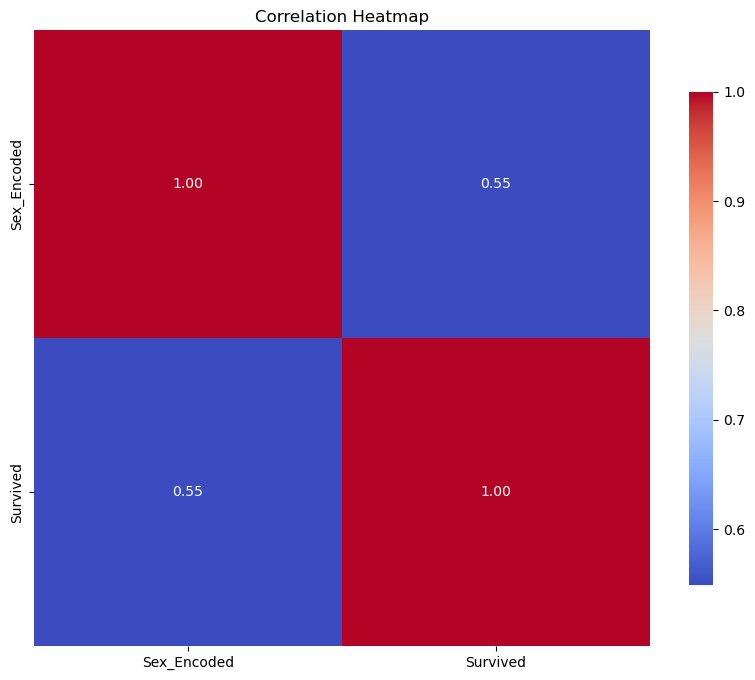

In [594]:
correlation_matrix = plot_corr_heatmap(X_train[vif_minimized_feature_list], y_train)

In [595]:
correlation_with_target = correlation_matrix[target].sort_values(ascending=False)
print("Correlation with target:")
print(correlation_with_target)

Correlation with target:
Survived       1.000000
Sex_Encoded    0.549171
Name: Survived, dtype: float64


## Model Development

In [596]:
mlflow.set_tracking_uri('http://ec2-18-220-145-217.us-east-2.compute.amazonaws.com:5000/')
mlflow.set_experiment('titanic_ml_from_disaster__abridged')

<Experiment: artifact_location='s3://thoughtswork-co/mlflow/3', creation_time=1749424560671, experiment_id='3', last_update_time=1749424560671, lifecycle_stage='active', name='titanic_ml_from_disaster__abridged', tags={}>

### Training Set Evaluation

In [611]:
# Train and evaluate a Logistic Regression model
numerical_features_to_test = vif_minimized_feature_list

X_numerical = X_train[numerical_features_to_test]

clf = LogisticRegression(
    random_state=42, 
    class_weight='balanced', 
    penalty='l1',  
    C=0.1,     
    max_iter=1000, 
    solver='liblinear')

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

with mlflow.start_run():
    mlflow.set_tag("dataset", "training")

    print(f"\nEvaluating model with training set of {len(X_numerical)} samples:")
    print(f"Features used:")
    for i, feat in enumerate(X_numerical.columns):
        print(f"* {feat}")
        mlflow.log_param(f"feature_{i}", feat)

    clf.fit(X_numerical, y_train)

    # Predict on training set to assess bias
    y_pred = clf.predict(X_numerical)

    acc  = accuracy_score(y_train, y_pred)
    prec = precision_score(y_train, y_pred, average='macro')
    rec  = recall_score(y_train, y_pred, average='macro')
    f1   = f1_score(y_train, y_pred, average='macro')

    mlflow.log_metrics({
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1_score": f1
    })

    print("\nTraining Set Scores:")
    print("Training accuracy :", acc)
    print("Training precision:", prec)
    print("Training recall   :", rec)
    print("Training F1-score :", f1)

    coef_df = pd.DataFrame(clf.coef_.T, index=X_numerical.columns, columns=['Coefficient'])
    print("\nModel Coefficients:")
    print(coef_df.sort_values(by='Coefficient', ascending=False))
    print()


Evaluating model with training set of 712 samples:
Features used:
* Sex_Encoded

Training Set Scores:
Training accuracy : 0.7893258426966292
Training precision: 0.778948909383692
Training recall   : 0.7702904536617521
Training F1-score : 0.7738955177115178

Model Coefficients:
             Coefficient
Sex_Encoded     2.094141

🏃 View run capable-smelt-999 at: http://ec2-18-220-145-217.us-east-2.compute.amazonaws.com:5000/#/experiments/3/runs/1ca4ff0c4fd84f5193183b858941de0c
🧪 View experiment at: http://ec2-18-220-145-217.us-east-2.compute.amazonaws.com:5000/#/experiments/3


In [598]:
print("\n" + "="*50)
print("DIAGNOSTIC ANALYSIS")
print("="*50)

# Check class distribution
print(f"Actual class distribution:")
print(f"Not Survived (0): {(y_train == 0).sum()} ({(y_train == 0).mean():.1%})")
print(f"Survived (1): {(y_train == 1).sum()} ({(y_train == 1).mean():.1%})")

print(f"\nPredicted class distribution:")
print(f"Not Survived (0): {(y_pred == 0).sum()} ({(y_pred == 0).mean():.1%})")
print(f"Survived (1): {(y_pred == 1).sum()} ({(y_pred == 1).mean():.1%})")

# Detailed classification report
print(f"\nDetailed Classification Report:")
print(classification_report(y_train, y_pred, target_names=['Not Survived', 'Survived']))

# Confusion matrix
print(f"\nConfusion Matrix:")
print(confusion_matrix(y_train, y_pred))


DIAGNOSTIC ANALYSIS
Actual class distribution:
Not Survived (0): 439 (61.7%)
Survived (1): 273 (38.3%)

Predicted class distribution:
Not Survived (0): 459 (64.5%)
Survived (1): 253 (35.5%)

Detailed Classification Report:
              precision    recall  f1-score   support

Not Survived       0.81      0.85      0.83       439
    Survived       0.74      0.69      0.71       273

    accuracy                           0.79       712
   macro avg       0.78      0.77      0.77       712
weighted avg       0.79      0.79      0.79       712


Confusion Matrix:
[[374  65]
 [ 85 188]]


### Test Set Evaluation

In [599]:
# Prepare validation set for prediction
X_val = engineer_features(X_val)
remove_duplicates(X_val, base_categorical_features + base_numerical_features, y_val)

Non-numeric Ticket Numbers in training data:
Ticket_Number
LINE    1
Name: count, dtype: int64
Number of duplicate rows in train set: 0
Number of duplicate rows in train set after dropping: 0



Evaluating model with 1 features:
* Sex_Encoded

Best parameters: {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}

Test Set Scores:
Test accuracy : 0.776536312849162
Test precision: 0.7671575437621562
Test recall   : 0.7533596837944664
Test F1-score : 0.7584345479082322
🏃 View run redolent-worm-864 at: http://ec2-18-220-145-217.us-east-2.compute.amazonaws.com:5000/#/experiments/3/runs/cbe3a74de14a4df9982a824b713d8e28
🧪 View experiment at: http://ec2-18-220-145-217.us-east-2.compute.amazonaws.com:5000/#/experiments/3

Model Coefficients:
             Coefficient
Sex_Encoded     2.496254


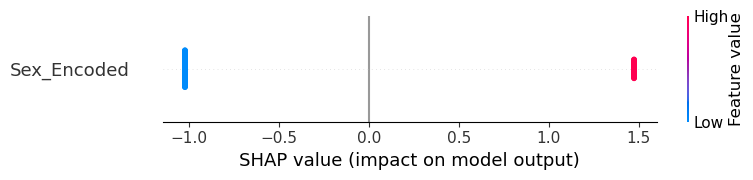

In [609]:
with mlflow.start_run():
    mlflow.set_tag("dataset", "test")

    print(f"\nEvaluating model with {len(X_numerical.columns)} features:")
    for i, feat in enumerate(X_numerical.columns):
        print(f"* {feat}")
        mlflow.log_param(f"feature_{i}", feat)

    param_grid = {
        'penalty': ['l1', 'l2'],
        'C': [1, 0.5, 0.1, 0.05, 0.01],
        'solver': ['liblinear'], 
    }

    search = GridSearchCV(clf, param_grid, cv=cv, scoring='f1') 
    search.fit(X_train[numerical_features_to_test], y_train)
    
    best_params = search.best_params_
    print(f"\nBest parameters: {best_params}")
    mlflow.log_params(best_params)

    clf = search.best_estimator_
    
    # y_probs = clf.predict_proba(X_val[numerical_features_to_test])[:, 1]
    # threshold = 0.4
    # y_pred = (y_probs >= threshold).astype(int)

    y_pred = clf.predict(X_val[numerical_features_to_test])

    acc  = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred, average='macro')
    rec  = recall_score(y_val, y_pred, average='macro')
    f1   = f1_score(y_val, y_pred, average='macro')

    print("\nTest Set Scores:")
    print("Test accuracy :", acc)
    print("Test precision:", prec)
    print("Test recall   :", rec)
    print("Test F1-score :", f1)

    mlflow.log_metrics({
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1_score": f1
    })

# Output clf coefficients
if hasattr(clf, 'coef_'):
    coef_df = pd.DataFrame(clf.coef_.T, index=X_numerical.columns, columns=['Coefficient'])
    print("\nModel Coefficients:")
    print(coef_df.sort_values(by='Coefficient', ascending=False))

# Output SHAP Summary Plot
# Ensure all data is proper numeric type
X_train_shap = X_train[numerical_features_to_test].astype(np.float64)
X_val_shap = X_val[numerical_features_to_test].astype(np.float64)
explainer   = shap.LinearExplainer(clf, X_train_shap)
shap_values = explainer.shap_values(X_val_shap)
shap.summary_plot(
    shap_values, X_val_shap, plot_type='dot', show=True,
    max_display=100
)

## Submission File Generation

In [601]:
submission_test_X = pd.read_csv('./input/test.csv')

In [602]:
submission_test_X.isnull().sum().loc[lambda x: x > 0]

Age       86
Fare       1
Cabin    327
dtype: int64

In [603]:
submission_test_X[submission_test_X['Fare'].isnull()]

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
152,1044,3,"Storey, Mr. Thomas",male,60.5,0,0,3701,NaN,NaN,S


In [604]:
submission_test_X['Fare'] = submission_test_X['Fare'].fillna(submission_test_X.groupby(['Pclass', 'Embarked'])['Fare'].transform('median'))

In [605]:
submission_test_X.isnull().sum().loc[lambda x: x > 0]

Age       86
Cabin    327
dtype: int64

In [606]:
submission_test_X = engineer_features(submission_test_X)
remove_duplicates(submission_test_X, base_categorical_features + base_numerical_features)

Non-numeric Ticket Numbers in training data:
Series([], Name: count, dtype: int64)
Number of duplicate rows in train set: 1
Number of duplicate rows in train set after dropping: 0


In [607]:
submission = pd.DataFrame({
    'PassengerId': submission_test_X['PassengerId'],
    'Survived': clf.predict(submission_test_X[numerical_features_to_test])
})
timestamp = datetime.now().strftime('%Y%m%d-%H%M%S')
filename = f'./submission-{timestamp}.csv'
submission.to_csv(filename, index=False)

-----------

In [608]:
import json
import re

def slugify(text):
    text = text.strip()
    text = re.sub(r'[^\w\s\-]', '', text)  # allow (), - and alphanumerics
    return re.sub(r'[\s]+', '-', text)

def extract_headings(ipynb_path):
    with open(ipynb_path, 'r', encoding='utf-8') as f:
        nb = json.load(f)

    toc_lines = [] # ["## Table of Contents\n"]
    for cell in nb['cells']:
        if cell['cell_type'] == 'markdown':
            for line in cell['source']:
                match = re.match(r'^(#{2,6})\s+(.*)', line)
                if match:
                    level = len(match.group(1)) - 1  # offset for nesting
                    title = match.group(2).strip()
                    anchor = slugify(title)
                    indent = '    ' * (level - 1)
                    toc_lines.append(f"{indent}1. [{title}](#{anchor})")

    return '\n'.join(toc_lines)

# Example usage:
toc = extract_headings("titanic_ml_from_disaster_abridged__paultongyoo.ipynb")
print(toc)

1. [Table of Contents](#Table-of-Contents)
1. [Introduction](#Introduction)
1. [Data Understanding](#Data-Understanding)
    1. [Data Dictionary](#Data-Dictionary)
        1. [Variable Notes](#Variable-Notes)
    1. [Descriptive Statistics](#Descriptive-Statistics)
    1. [Row Samples](#Row-Samples)
    1. [Data Types](#Data-Types)
    1. [Missing Values Summary](#Missing-Values-Summary)
    1. [Sample Visual Inspection](#Sample-Visual-Inspection)
1. [Feature Engineering](#Feature-Engineering)
1. [Exploratory Data Analysis](#Exploratory-Data-Analysis)
1. [Model Development](#Model-Development)
    1. [Model Eval on Training Set](#Model-Eval-on-Training-Set)
1. [Generalization Test](#Generalization-Test)
1. [Submission File Generation](#Submission-File-Generation)
